In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, interactive, fixed, interact_manual, HBox
import ipywidgets as widgets
%matplotlib widget

In [ ]:

import sys
vrae_path = r'C:\Users\achfr\timeseries-clustering-vae'
if vrae_path not in sys.path:
    sys.path.append(vrae_path)
from vrae.vrae import VRAE
from vrae.utils import *


import numpy as np
import torch
import torch.nn as nn   
import pandas as pd
import plotly
from torch.utils.data import DataLoader, TensorDataset
plotly.offline.init_notebook_mode()
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from sklearn.model_selection import train_test_split
import seaborn as sns

import sklearn.metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier



latent_length = 12
##################
sequence_length = 72
number_of_features = 1

dload = './model_dir_mm' #download directory
hidden_size = 90
hidden_layer_depth = 2
batch_size = 1
learning_rate = 0.001 # 0.0005
n_epochs = 200
dropout_rate = 0.2
optimizer = 'Adam' # options: ADAM, SGD
cuda = True # options: True, False
print_every=1000
clip = True # options: True, False
max_grad_norm=5
loss = 'MSELoss' # options: SmoothL1Loss, MSELoss
block = 'LSTM' # options: LSTM, GRU

vrae = VRAE(sequence_length=sequence_length,
            number_of_features = number_of_features,
            hidden_size = hidden_size, 
            hidden_layer_depth = hidden_layer_depth,
            latent_length = latent_length,
            batch_size = batch_size,
            learning_rate = learning_rate,
            n_epochs = n_epochs,
            dropout_rate = dropout_rate,
            optimizer = optimizer, 
            cuda = cuda,
            print_every=print_every, 
            clip=clip, 
            max_grad_norm=max_grad_norm,
            loss = loss,
            block = block,
            dload = dload)

# vrae.load(fr'C:\Users\achfr\timeseries-clustering-vae\latent_results_test\model_{latent_length}.pth')
vrae.load(fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_savebest\model_3_{latent_length}.pth')

interactive(children=(FloatSlider(value=0.5, description='l1', layout=Layout(width='500px'), max=2.0, min=-2.0…

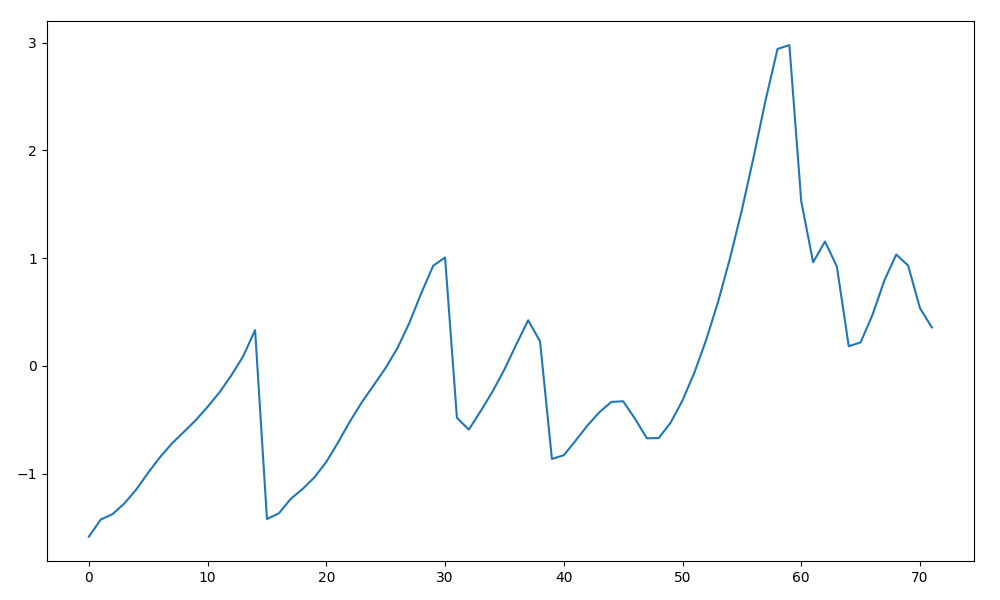

In [11]:
latentest = [0.5]*12

def generate(latent):
    recons = vrae.decoder(torch.tensor(np.array(latent)[None,:]).float().cuda())
    return(recons[:,0,0].cpu().detach().numpy())

fig,ax = plt.subplots(1,1, figsize = (10,6))
fig.tight_layout()

def plot(l1, l2, l3, l4, l5, l6, l7, l8, l9, l10, l11, l12):
    ax.cla()
    ax.plot(generate([l1, l2, l3, l4, l5, l6, l7, l8, l9, l10, l11, l12]))

sliders = [widgets.FloatSlider(min=-2, max=2, step=0.01, value=0.5,layout=widgets.Layout(width='500px')) for _ in range(12)]
slider_box = HBox(sliders)

interact(plot, l1=sliders[0], l2=sliders[1], l3=sliders[2], l4=sliders[3], l5=sliders[4], l6=sliders[5],
                l7=sliders[6], l8=sliders[7], l9=sliders[8], l10=sliders[9], l11=sliders[10], l12=sliders[11])
a=0
# display(slider_box)

In [ ]:
def last_noNaN_index(serie):
    return((~np.isnan(serie.flatten())).cumsum(0).argmax(0))
    
def death_split(data, rates, treshold):
    return(
        data[[bool(serie[last_noNaN_index(serie)] <= treshold) for serie in rates],:,0],
        data[[bool(serie[last_noNaN_index(serie)] > treshold) for serie in rates],:,0])

def clean_set_length(dat, length):
    dat = dat[[bool(last_noNaN_index(i) >length) for i in dat]]
    return(dat[:,:length])

res_nohyp = np.load('reslistnohyper.npy', allow_pickle = True)
mean_nohyp, std_nohyp = np.array([np.mean(i[2]["test_score"]) for i in res_nohyp]), np.array([np.std(i[2]["test_score"]) for i in res_nohyp])
res_random = np.load('reslist_random_11h.npy', allow_pickle = True)
mean_random, std_random = np.array([np.mean(i[0]) for i in res_random]), np.array([np.std(i[0]) for i in res_random])
res_bayes = np.load('reslist_bayes_11h.npy', allow_pickle = True)
mean_bayes, std_bayes = np.array([-1*i[0].trials[-1]['result']['loss'] for i in res_bayes]), np.array([i[0].trials[-1]['result']['std'] for i in res_bayes])
data_dict = np.load("raw_dict.npy", allow_pickle=True).item()
fluotraj = clean_set_length(data_dict['glu_cip']["MeanIntensity_gfp"], 260)[:,:,0]

fig,ax = plt.subplots(2,1, figsize = (10,7))
fig.tight_layout()
minf,maxf = np.nanmin(fluotraj), np.nanmax(fluotraj)

def plot(up_to):
    ax[0].cla()
    ax[1].cla()
    ax[0].plot(np.array(range(10,270))[:(up_to-1)*10]*(1/12), fluotraj[:,:(up_to-1)*10].T, linewidth = 0.5, alpha=0.3, color = 'blue')
    ax[0].set_yscale('log')
    ax[0].set_xlim(0,23)
    ax[0].set_title("GFP fluorescence")
    ax[0].plot((2,2),(minf,maxf),color='black',alpha=0.3)
    ax[0].plot((14,14),(minf,maxf),color='black',alpha=0.3)

    ax[1].plot(np.array(range(10,270,10))[:up_to]*(1/12), mean_nohyp[:up_to], color = "blue", label = 'no hyperparam tuning')
    ax[1].fill_between(np.array(range(10,270,10))[:up_to]*(1/12), mean_nohyp[:up_to] - std_nohyp[:up_to], mean_nohyp[:up_to] + std_nohyp[:up_to], alpha=0.3, edgecolor='blue', facecolor='blue')
    ax[1].errorbar(np.array(range(10,270,10))[:up_to]*(1/12), mean_random[:up_to], color = "red", label = 'random search')
    ax[1].fill_between(np.array(range(10,270,10))[:up_to]*(1/12), mean_random[:up_to] - std_random[:up_to], mean_random[:up_to] + std_random[:up_to], alpha=0.3, edgecolor='red', facecolor='red')
    ax[1].plot(np.array(range(10,270,10))[:up_to]*(1/12), mean_bayes[:up_to], color = "orange", label = 'bayesian search')
    ax[1].fill_between(np.array(range(10,270,10))[:up_to]*(1/12), mean_bayes[:up_to] - std_bayes[:up_to], mean_bayes[:up_to] + std_bayes[:up_to], alpha=0.3, edgecolor='orange', facecolor='orange')
    ax[1].plot((2,2),(0.4,1),color='black',linewidth = 0.7, alpha=0.7)
    ax[1].plot((14,14),(0.4,1),color='black',linewidth = 0.7, alpha=0.7)
    ax[1].set_xlim(0,23)
    ax[1].set_title("AUROC test score using increasing ammount of timepoints, mean over the 10 folds +- std")
    ax[1].legend()
    ax[1].set_xlabel("length used for forecasting(h)")

interact(plot, up_to=widgets.IntSlider(min=1, max=26, step=1, value=26))